In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load data
df = pd.read_csv('cleaned_urls.csv')

# Separate features and target
X = df.drop(columns=['label', 'domain', 'ip'])
y = df['label']

In [9]:
# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [10]:
# Predict
y_pred = rf_model.predict(X_test)

In [11]:
# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred))

Random Forest Accuracy: 0.7208309662362389
Random Forest Confusion Matrix:
 [[62220  6133  1274 16250]
 [  120 13127   419  5442]
 [   89   220  5439   716]
 [ 2002  2995   704 13108]]
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.72      0.83     85877
           1       0.58      0.69      0.63     19108
           2       0.69      0.84      0.76      6464
           3       0.37      0.70      0.48     18809

    accuracy                           0.72    130258
   macro avg       0.65      0.74      0.68    130258
weighted avg       0.81      0.72      0.75    130258



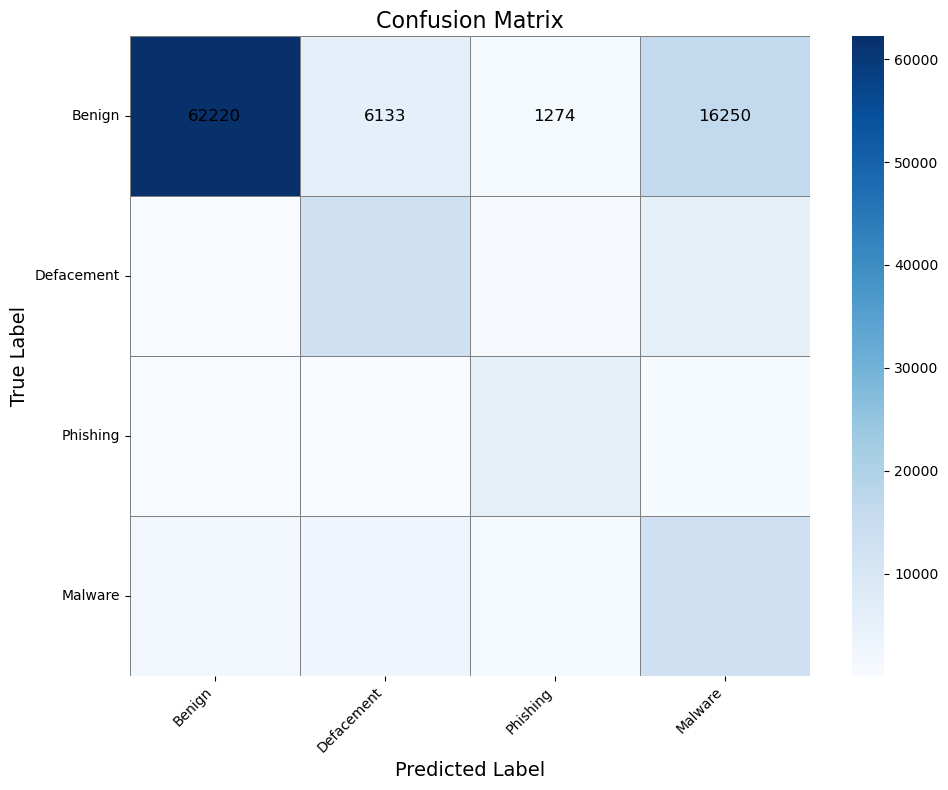

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([
    [62220, 6133, 1274, 16250],
    [120, 13127, 419, 5442],
    [89, 220, 5439, 716],
    [2002, 2995, 704, 13108]
], dtype=int)

labels = ['Benign', 'Defacement', 'Phishing', 'Malware']

plt.figure(figsize=(10, 8))

# Using a slightly darker colormap might help, or stick with 'Blues'
# if the issue is truly just visibility due to small numbers and light background.
# 'Blues' is generally good, but ensure the annot_kws color provides enough contrast.
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=labels, yticklabels=labels,
                 annot_kws={"size": 12, "color": "black"}, # Ensure good contrast
                 linewidths=0.5, linecolor='gray')

plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.xticks(rotation=45, ha='right') # Added ha='right' for better label alignment
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [24]:
print("Shape of confusion matrix:", cm.shape)
print("Type of confusion matrix:", type(cm))
print("Data type of matrix entries:", cm.dtype)

Shape of confusion matrix: (4, 4)
Type of confusion matrix: <class 'numpy.ndarray'>
Data type of matrix entries: int32


In [29]:
import matplotlib
import seaborn

print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", seaborn.__version__)

Matplotlib version: 3.8.0
Seaborn version: 0.12.2
